In [1]:
import mlflow
mlflow.set_tracking_uri("sqlite:///C:/Users/camer/projects/ev_load_fc/mlflow_store/mlflow.db")

from ev_load_fc.training.mlflow_api import get_best_model
from ev_load_fc.config import CFG
import pandas as pd
import matplotlib.pyplot as plt
train = pd.read_csv(r'C:\Users\camer\projects\ev_load_fc\datasets\04_features\train_detrend_f_30_rfe_20.csv', parse_dates=True, index_col='timestamp')
test  = pd.read_csv(r'C:\Users\camer\projects\ev_load_fc\datasets\04_features\test_detrend_f_30_rfe_20.csv', parse_dates=True, index_col='timestamp')
split_date = CFG['data']['preprocessing']['split_date']

X_train = train.drop(columns='energy')
y_train = train['energy']
X_test  = test.drop(columns='energy')
y_test  = test['energy']

c:\Users\camer\projects\ev_load_fc\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
print(y_train.min())

-48.71728618103692


In [3]:
tree_exp = 'Ensemble Models Detrend'
# filter_string = 'tags.model_family = "XGBoost"'
model, best_run = get_best_model(tree_exp, 'rmse', filter_string=None)

MLflow tracking URI : sqlite:///C:/Users/camer/projects/ev_load_fc/mlflow_store/mlflow.db
DB exists           : True


2026/03/02 12:17:11 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/03/02 12:17:11 INFO mlflow.store.db.utils: Updating database tables
2026/03/02 12:17:11 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/03/02 12:17:11 INFO alembic.runtime.migration: Will assume non-transactional DDL.
2026/03/02 12:17:11 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/03/02 12:17:11 INFO alembic.runtime.migration: Will assume non-transactional DDL.

Best run ID : 31b74618206e447d8d0c499997351dfc
Best rmse  : -24.9218
Model        : able-gnu-129


In [4]:
model.get_params()

{'fold_len_multiplier': 2.021940609,
 'random_strength': 0.5234048641,
 'leaf_estimation_iterations': 8,
 'border_count': 134,
 'score_function': 'Cosine',
 'fold_permutation_block': 202,
 'bootstrap_type': 'MVS',
 'boosting_type': 'Ordered',
 'leaf_estimation_method': 'Newton',
 'iterations': 192,
 'verbose': 0,
 'loss_function': 'RMSE',
 'l2_leaf_reg': 7.980919892,
 'subsample': 0.6338930618,
 'depth': 6,
 'learning_rate': 0.06540908638}

In [5]:
preds = model.predict(X_test)

In [6]:
preds.min()

np.float64(-50.34278350601213)

In [7]:
def get_experiment_metrics(experiment_name: str) -> list[str]:
    """Returns a list of all metrics logged across runs in a given experiment."""
    experiment = mlflow.get_experiment_by_name(experiment_name)
    if experiment is None:
        raise ValueError(f"Experiment '{experiment_name}' not found.")

    runs = mlflow.search_runs(
        experiment_ids=[experiment.experiment_id],
        filter_string="status = 'FINISHED'",
    )

    metric_cols = [col.replace("metrics.", "") for col in runs.columns if col.startswith("metrics.")]
    return metric_cols

In [8]:
def plot_forecast(y_train, y_test, preds, history_start=None,preds_start=None, preds_end=None):
    """
    Plot forecast predictions vs actuals with historical context.

    Parameters
    ----------
    y_train : pd.Series with DatetimeIndex - historical data
    y_test  : pd.Series with DatetimeIndex - actuals
    preds   : pd.Series with DatetimeIndex - forecast predictions
    history_start : str or datetime, optional - slice start for history shown
    history_end   : str or datetime, optional - slice end for history shown
    """
    history = y_train.loc[history_start:]
    preds_s = pd.Series(preds, index=y_test.index)
    preds_s = preds_s.loc[preds_start:preds_end]
    y_test  = y_test.loc[preds_start:preds_end]

    fig, ax = plt.subplots(figsize=(12, 5))

    ax.plot(history.index, history.values, color="steelblue", label="History")
    ax.plot(y_test.index, y_test.values, color="green", label="Actuals")
    ax.plot(preds_s.index, preds_s, color="red", linestyle="--", label="Forecast")

    ax.axvline(y_test.index[0], color="gray", linestyle=":", lw=1)
    ax.legend()
    ax.set_title("Forecast vs Actuals")
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()

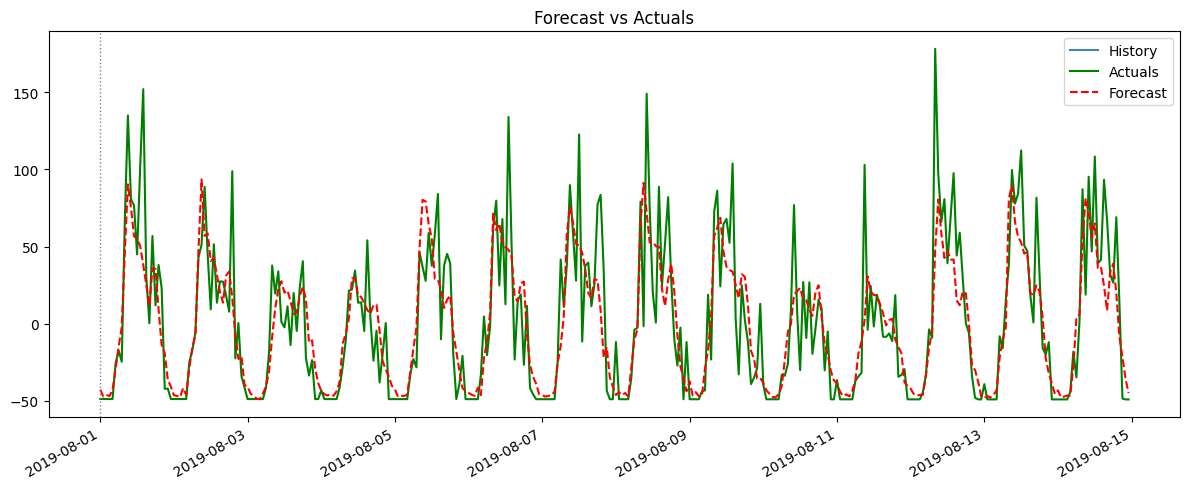

In [9]:
plot_forecast(y_train, y_test, preds, history_start='2019-08-01', preds_end='2019-08-14')

# Inference